# MRR Bridge Analysis
**Dataset:** RavenStack — 5,000 subscription records  
**Goal:** Decompose monthly MRR movement into New / Expansion / Contraction / Churned / Net New components

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Libraries loaded.')

Libraries loaded.


In [2]:
subs = pd.read_csv('../data/subscriptions.csv', parse_dates=['start_date', 'end_date'])
print(f'Subscriptions: {len(subs):,} rows')
print(f'Date range: {subs.start_date.min().date()} → {subs.start_date.max().date()}')
print(f'\nChurn flag distribution:')
print(subs['churn_flag'].value_counts())
print(f'\nUpgrade flag distribution:')
print(subs['upgrade_flag'].value_counts())
print(f'\nMRR stats (non-trial):')
print(subs[subs['is_trial']==False]['mrr_amount'].describe().round(2))

Subscriptions: 5,000 rows
Date range: 2023-01-09 → 2024-12-31

Churn flag distribution:
churn_flag
False    4514
True      486
Name: count, dtype: int64

Upgrade flag distribution:
upgrade_flag
False    4471
True      529
Name: count, dtype: int64

MRR stats (non-trial):
count     4222.00
mean      2685.63
std       3569.43
min         19.00
25%        539.00
50%       1244.50
75%       3381.00
max      33830.00
Name: mrr_amount, dtype: float64


## Step 1: Assign each subscription to a calendar month bucket

In [3]:
subs['start_month'] = subs['start_date'].dt.to_period('M')
subs['end_month']   = subs['end_date'].dt.to_period('M')

# Build a complete monthly calendar spanning the dataset
all_months = pd.period_range(
    start=subs['start_date'].min().to_period('M'),
    end=subs['start_date'].max().to_period('M'),
    freq='M'
)
print(f'Monthly periods: {all_months[0]} → {all_months[-1]} ({len(all_months)} months)')

Monthly periods: 2023-01 → 2024-12 (24 months)


## Step 2: Pre-compute contraction pairs (downgrade events)

A downgrade creates two subscription records: the old one ending, and a new one starting with `downgrade_flag = True`.  
Contraction MRR = old_mrr − new_mrr (the revenue lost per downgrade event).  
This is computed once before the monthly loop and used as a lookup.

In [4]:
# --- Pre-compute contraction pairs ---
# For each subscription with downgrade_flag=True, find the previous subscription
# for the same account (the one that ended just before this one started).
# Contraction MRR = prev_mrr - new_mrr (clipped at 0 in case of data quirks).

downgrade_subs = subs[
    (subs['downgrade_flag'] == True) & (subs['is_trial'] == False)
].copy()

prev_mrr_values = []
for _, row in downgrade_subs.iterrows():
    prev = subs[
        (subs['account_id'] == row['account_id']) &
        (subs['end_date'] <= row['start_date']) &
        (subs['subscription_id'] != row['subscription_id'])
    ]
    if len(prev) > 0:
        prev_mrr_values.append(prev.sort_values('end_date').iloc[-1]['mrr_amount'])
    else:
        prev_mrr_values.append(row['mrr_amount'])  # no predecessor found → 0 contraction

downgrade_subs = downgrade_subs.copy()
downgrade_subs['prev_mrr'] = prev_mrr_values
downgrade_subs['contraction_amount'] = (
    downgrade_subs['prev_mrr'] - downgrade_subs['mrr_amount']
).clip(lower=0)
downgrade_subs['start_month'] = downgrade_subs['start_date'].dt.to_period('M')

# Accounts that downgraded in a given month (used to exclude from Churned MRR)
downgrade_accounts_by_month = (
    downgrade_subs.groupby('start_month')['account_id'].apply(set).to_dict()
)

print(f'Downgrade events found: {len(downgrade_subs)}')
print(f'Total contraction MRR (all months): ${downgrade_subs["contraction_amount"].sum():,.0f}')
print(f'Avg contraction per event: ${downgrade_subs["contraction_amount"].mean():,.0f}')

# --- Build MRR Bridge — New / Expansion / Contraction / Churned / Net New ---
records = []

for month in all_months:
    # Accounts that downgraded this month (their old sub ending ≠ churn)
    downgraded_accounts = downgrade_accounts_by_month.get(month, set())

    # NEW MRR: brand-new paid subscriptions (not upgrade, not downgrade)
    new_mask = (
        (subs['start_month'] == month) &
        (subs['is_trial'] == False) &
        (subs['upgrade_flag'] == False) &
        (subs['downgrade_flag'] == False)
    )
    new_mrr = subs.loc[new_mask, 'mrr_amount'].sum()

    # EXPANSION MRR: upgrades that started this month
    expansion_mask = (
        (subs['start_month'] == month) &
        (subs['upgrade_flag'] == True) &
        (subs['is_trial'] == False)
    )
    expansion_mrr = subs.loc[expansion_mask, 'mrr_amount'].sum()

    # CONTRACTION MRR: MRR lost from accounts that downgraded this month
    contraction_mrr = downgrade_subs.loc[
        downgrade_subs['start_month'] == month, 'contraction_amount'
    ].sum()

    # CHURNED MRR: subscriptions that fully ended this month,
    # excluding accounts that merely downgraded (they're in Contraction)
    churn_mask = (
        (subs['end_month'] == month) &
        (subs['churn_flag'] == True) &
        (~subs['account_id'].isin(downgraded_accounts))
    )
    churned_mrr = subs.loc[churn_mask, 'mrr_amount'].sum()

    net_new_mrr = new_mrr + expansion_mrr - contraction_mrr - churned_mrr

    records.append({
        'month': month,
        'new_mrr': new_mrr,
        'expansion_mrr': expansion_mrr,
        'contraction_mrr': contraction_mrr,
        'churned_mrr': churned_mrr,
        'net_new_mrr': net_new_mrr
    })

bridge = pd.DataFrame(records)
bridge['month_str'] = bridge['month'].dt.strftime('%b %Y')
bridge['cumulative_mrr'] = bridge['net_new_mrr'].cumsum()

print('\nMRR Bridge (monthly, first 6 rows):')
print(bridge[['month_str', 'new_mrr', 'expansion_mrr', 'contraction_mrr', 'churned_mrr', 'net_new_mrr']].head(6).to_string(index=False))
print(f'\nTotal New MRR:         ${bridge["new_mrr"].sum():,.0f}')
print(f'Total Expansion MRR:   ${bridge["expansion_mrr"].sum():,.0f}')
print(f'Total Contraction MRR: ${bridge["contraction_mrr"].sum():,.0f}')
print(f'Total Churned MRR:     ${bridge["churned_mrr"].sum():,.0f}')
print(f'Net MRR over period:   ${bridge["net_new_mrr"].sum():,.0f}')

Downgrade events found: 188
Total contraction MRR (all months): $22,700
Avg contraction per event: $121

MRR Bridge (monthly, first 6 rows):
month_str  new_mrr  expansion_mrr  contraction_mrr  churned_mrr  net_new_mrr
 Jan 2023     1102           3582                0            0         4684
 Feb 2023     9484             76                0            0         9560
 Mar 2023    19881           6004                0            0        25885
 Apr 2023    31158           6733                0          245        37646
 May 2023    67753          12139                0            0        79892
 Jun 2023    52656          18402                0         1176        69882

Total New MRR:         $9,656,818
Total Expansion MRR:   $1,262,997
Total Contraction MRR: $22,700
Total Churned MRR:     $1,117,839
Net MRR over period:   $9,779,276


## Step 3: MRR Bridge Chart — 5-component waterfall

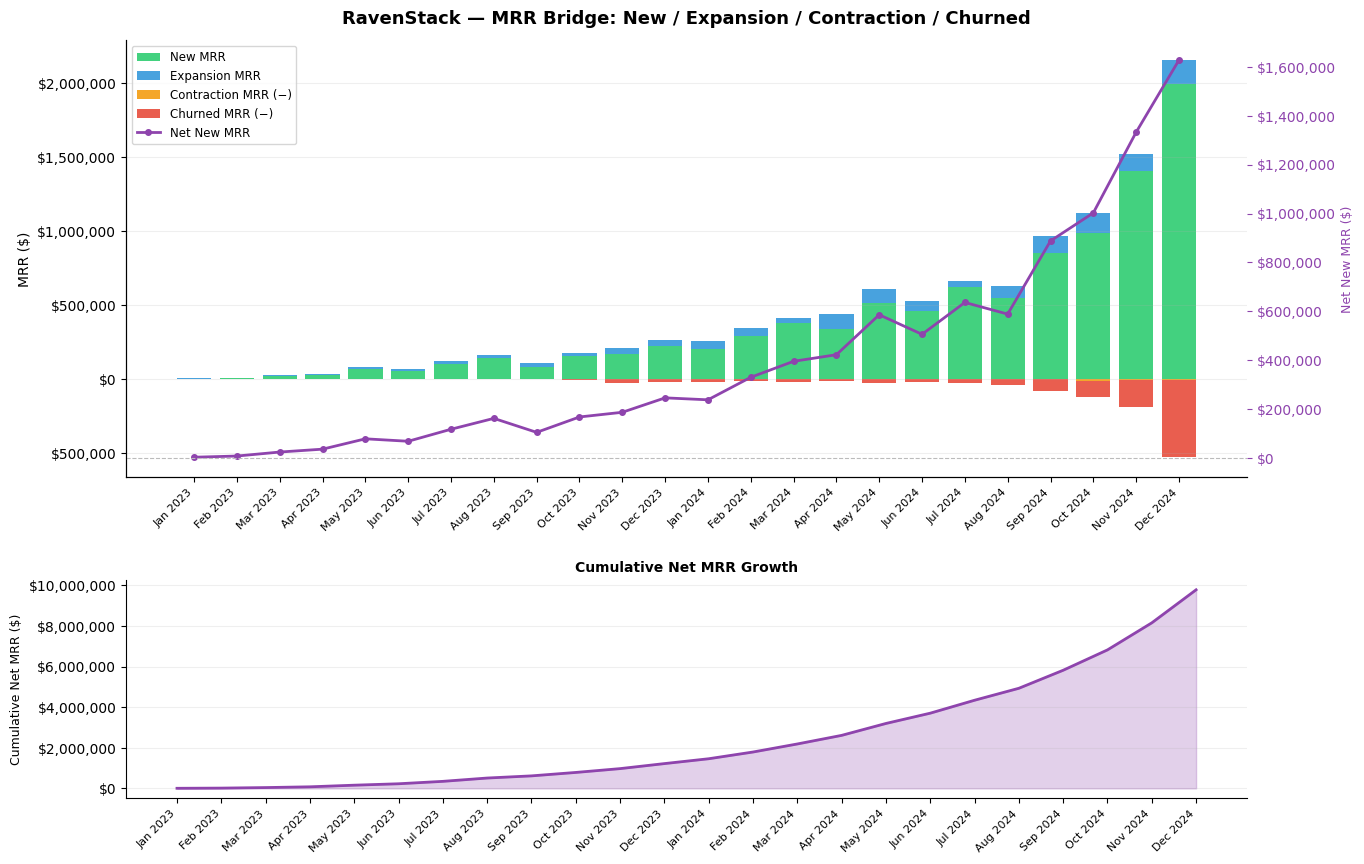

Saved: mrr_bridge.png


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]})

months_idx = range(len(bridge))
x_labels = bridge['month_str'].tolist()

C_NEW         = '#2ecc71'   # green  — new revenue
C_EXP         = '#3498db'   # blue   — expansion
C_CONTRACTION = '#f39c12'   # orange — contraction (downgrade)
C_CHURN       = '#e74c3c'   # red    — full churn
C_NET         = '#8e44ad'   # purple — net new

# --- Top chart: stacked positive (New + Expansion) and negative (Contraction + Churned) ---
ax1.bar(months_idx, bridge['new_mrr'],
        color=C_NEW, alpha=0.9, label='New MRR')
ax1.bar(months_idx, bridge['expansion_mrr'],
        color=C_EXP, alpha=0.9, label='Expansion MRR',
        bottom=bridge['new_mrr'])

# Negative stack: contraction first (closer to zero), then churn below
ax1.bar(months_idx, -bridge['contraction_mrr'],
        color=C_CONTRACTION, alpha=0.9, label='Contraction MRR (−)')
ax1.bar(months_idx, -bridge['churned_mrr'],
        color=C_CHURN, alpha=0.9, label='Churned MRR (−)',
        bottom=-bridge['contraction_mrr'])

# Net New MRR overlay line
ax1_twin = ax1.twinx()
ax1_twin.plot(months_idx, bridge['net_new_mrr'], color=C_NET,
              linewidth=2, marker='o', markersize=4, label='Net New MRR')
ax1_twin.axhline(0, color='#bbb', linewidth=0.8, linestyle='--')
ax1_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1_twin.set_ylabel('Net New MRR ($)', color=C_NET, fontsize=9)
ax1_twin.tick_params(axis='y', colors=C_NET)
ax1_twin.spines['top'].set_visible(False)

ax1.set_xticks(months_idx)
ax1.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${abs(x):,.0f}'))
ax1.set_ylabel('MRR ($)', fontsize=10)
ax1.set_title('RavenStack — MRR Bridge: New / Expansion / Contraction / Churned',
              fontsize=13, fontweight='bold', pad=12)
ax1.grid(axis='y', alpha=0.2)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', fontsize=8.5)

# --- Bottom chart: Cumulative Net MRR ---
ax2.fill_between(months_idx, bridge['cumulative_mrr'], alpha=0.25, color=C_NET)
ax2.plot(months_idx, bridge['cumulative_mrr'], color=C_NET, linewidth=2)
ax2.set_xticks(months_idx)
ax2.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_ylabel('Cumulative Net MRR ($)', fontsize=9)
ax2.set_title('Cumulative Net MRR Growth', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.2)

plt.tight_layout(pad=2)
plt.savefig('../outputs/mrr_bridge.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mrr_bridge.png')

## Step 4: MRR Bridge by Plan Tier

In [6]:
tier_summary = []
for tier in ['Basic', 'Pro', 'Enterprise']:
    t = subs[(subs['plan_tier'] == tier) & (subs['is_trial'] == False)]

    new_mrr        = t[(t['upgrade_flag'] == False) & (t['downgrade_flag'] == False)]['mrr_amount'].sum()
    exp_mrr        = t[t['upgrade_flag'] == True]['mrr_amount'].sum()
    contraction    = downgrade_subs[downgrade_subs['plan_tier'] == tier]['contraction_amount'].sum()
    churn_mrr      = t[
        (t['churn_flag'] == True) &
        (~t['account_id'].isin(downgrade_subs['account_id']))
    ]['mrr_amount'].sum()
    active_mrr     = t[t['churn_flag'] == False]['mrr_amount'].sum()

    tier_summary.append({
        'Tier':             tier,
        'New MRR':          f'${new_mrr:,.0f}',
        'Expansion MRR':    f'${exp_mrr:,.0f}',
        'Contraction MRR':  f'${contraction:,.0f}',
        'Churned MRR':      f'${churn_mrr:,.0f}',
        'Active MRR':       f'${active_mrr:,.0f}',
    })

tier_df = pd.DataFrame(tier_summary)
print('MRR Summary by Plan Tier (5-component bridge):')
print(tier_df.to_string(index=False))

MRR Summary by Plan Tier (5-component bridge):
      Tier    New MRR Expansion MRR Contraction MRR Churned MRR Active MRR
     Basic   $676,020       $60,116         $15,288     $47,234   $687,914
       Pro $1,720,880      $281,113          $3,830    $117,796 $1,924,818
Enterprise $7,259,918      $921,768          $3,582    $682,968 $7,546,876


## Step 5: Key Findings

In [7]:
best_month_idx  = bridge['new_mrr'].idxmax()
worst_churn_idx = bridge['churned_mrr'].idxmax()
worst_cont_idx  = bridge['contraction_mrr'].idxmax()

print('=' * 60)
print('KEY FINDINGS — MRR BRIDGE (5-COMPONENT)')
print('=' * 60)
print(f'Total New MRR:           ${bridge["new_mrr"].sum():>12,.0f}')
print(f'Total Expansion MRR:     ${bridge["expansion_mrr"].sum():>12,.0f}')
print(f'Total Contraction MRR:   ${bridge["contraction_mrr"].sum():>12,.0f}')
print(f'Total Churned MRR:       ${bridge["churned_mrr"].sum():>12,.0f}')
print(f'Net MRR over period:     ${bridge["net_new_mrr"].sum():>12,.0f}')
print()
print(f'Peak new MRR month:      {bridge.loc[best_month_idx, "month_str"]} (${bridge.loc[best_month_idx, "new_mrr"]:,.0f})')
print(f'Peak churn month:        {bridge.loc[worst_churn_idx, "month_str"]} (${bridge.loc[worst_churn_idx, "churned_mrr"]:,.0f})')
print(f'Peak contraction month:  {bridge.loc[worst_cont_idx, "month_str"]} (${bridge.loc[worst_cont_idx, "contraction_mrr"]:,.0f})')
net_positive = (bridge['net_new_mrr'] > 0).sum()
print(f'Months with net growth:  {net_positive}/{len(bridge)}')

# Contraction vs churn ratio
total_rev_at_risk = bridge['contraction_mrr'].sum() + bridge['churned_mrr'].sum()
contraction_share = bridge['contraction_mrr'].sum() / total_rev_at_risk * 100
print(f'\nContraction share of total MRR at-risk: {contraction_share:.0f}%')
print('(Contraction accounts are retained; Churned are lost entirely)')
print('=' * 60)

KEY FINDINGS — MRR BRIDGE (5-COMPONENT)
Total New MRR:           $   9,656,818
Total Expansion MRR:     $   1,262,997
Total Contraction MRR:   $      22,700
Total Churned MRR:       $   1,117,839
Net MRR over period:     $   9,779,276

Peak new MRR month:      Dec 2024 ($1,993,577)
Peak churn month:        Dec 2024 ($524,180)
Peak contraction month:  Oct 2024 ($11,296)
Months with net growth:  24/24

Contraction share of total MRR at-risk: 2%
(Contraction accounts are retained; Churned are lost entirely)
